# Autoencoder — Anomaly Detection
### EngineFaultDB Dataset

The autoencoder is trained exclusively on healthy engine data. It learns to
compress and reconstruct normal sensor readings — when fault data passes through,
reconstruction fails because the model has only learned healthy patterns.
That reconstruction error is the anomaly signal.


In [2]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import tensorflow as tf
import random
import joblib
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, fbeta_score, recall_score,
    precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)


In [3]:
dataset = pd.read_csv('../data/EngineFaultDB_Final.csv')


## Prepare the Dataset for Training the Autoencoder

This dataset contains 4 categories of faulty engine data:

- No fault (0)
- Fault type 1
- Fault type 2
- Fault type 3

As we are trying to get the autoencoder to realise what "healthy" engine data looks like,
we don't need the faulty data, so the first step is to create a dataset of only the healthy data.


In [4]:
healthy_data = dataset[dataset["Fault"] == 0]
healthy_data.shape


(16000, 15)

In [5]:
healthy_data = healthy_data.drop(columns=["Fault"])
healthy_data.shape


(16000, 14)

In [6]:
healthy_input = healthy_data.values


In [7]:
healthy_train, healthy_test = train_test_split(healthy_input, test_size=0.2, random_state=42)
print(f"the length of the healthy train data is {len(healthy_train)}")
print(f"the length of the healthy test data is {len(healthy_test)}")


the length of the healthy train data is 12800
the length of the healthy test data is 3200


In [ ]:
from sklearn.preprocessing import StandardScaler


pipeline = Pipeline([
    ('scaler', StandardScaler())
])
pipeline.fit(healthy_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [9]:
train_transformed = pipeline.transform(healthy_train)
test_transformed = pipeline.transform(healthy_test)


In [10]:
df = pd.DataFrame(train_transformed, columns=healthy_data.columns)
df.head()


,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,1.544885,0.373551,-0.812604,0.217375,-1.049317,-0.910380,1.048128,-1.097573,-1.222595,0.029964,1.277724,2.070932,1.167916,1.159002
1,-0.359300,-0.424989,-0.537316,-0.436762,1.273279,0.313113,-1.351427,1.543734,-1.115306,-0.629436,0.756499,0.456316,0.549752,0.551199
2,1.263957,0.332880,1.679314,2.365385,0.675141,2.095809,1.045352,0.662953,-0.951818,-0.030888,0.958185,-0.601850,0.886932,0.890141
3,-0.536030,-0.454749,-0.562150,-0.580444,0.718474,0.790500,-0.293494,0.701597,1.112945,0.044994,-1.638219,-1.482135,-1.435866,-1.442957
4,-0.359300,-0.384319,-0.532794,-0.445844,1.265296,0.413694,-1.422696,1.309488,-1.118955,-0.658014,1.118562,0.428950,0.774539,0.772913


## Model Engineering and Training

In [11]:
input_dimension = train_transformed.shape[1]


In [12]:
def build_autoencoder(bottleneck_size):
    m = Sequential()
    m.add(Dense(10, input_dim=input_dimension, activation='relu'))
    m.add(Dense(bottleneck_size, activation='relu'))
    m.add(Dense(10, activation='relu'))
    m.add(Dense(input_dimension))
    m.compile(optimizer='adam', loss='mse')
    return m


In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    min_delta=1e-4,
    restore_best_weights=True
)


In [14]:
bottleneck_results = {}
for b in [2, 3, 4, 5, 6]:
    m = build_autoencoder(b)
    h = m.fit(
        train_transformed, train_transformed,
        epochs=1000, batch_size=256, verbose=0,
        validation_data=(test_transformed, test_transformed),
        callbacks=[EarlyStopping(patience=30, min_delta=1e-4,
                                 restore_best_weights=True)]
    )
    bottleneck_results[b] = min(h.history["val_loss"])
    print(f"Bottleneck {b}: val_loss = {bottleneck_results[b]:.6f}")


e:\AISP\2nd semester\Machine Learning\Anomaly_Detection\venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bottleneck 2: val_loss = 0.079604
Bottleneck 3: val_loss = 0.022249
Bottleneck 4: val_loss = 0.009254
Bottleneck 5: val_loss = 0.008101
Bottleneck 6: val_loss = 0.006654


In [15]:
best_bottleneck = min(bottleneck_results, key=bottleneck_results.get)
print(f"\nBest bottleneck: {best_bottleneck}")



Best bottleneck: 6


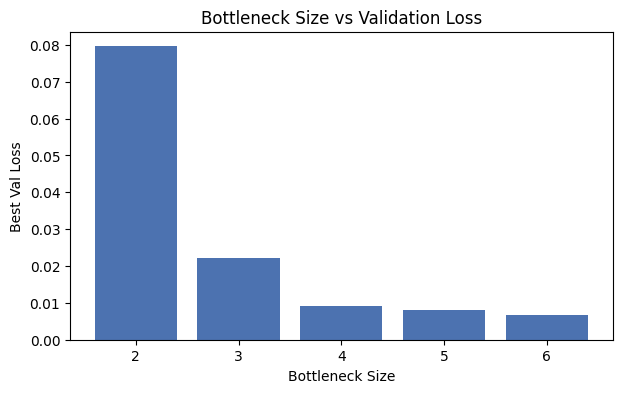

In [16]:
plt.figure(figsize=(7, 4))
plt.bar(bottleneck_results.keys(), bottleneck_results.values(),
        color="#4C72B0")
plt.xlabel("Bottleneck Size")
plt.ylabel("Best Val Loss")
plt.title("Bottleneck Size vs Validation Loss")
plt.savefig("../figures/bottleneck_tuning.png", bbox_inches="tight")
plt.show()


In [17]:
model = build_autoencoder(best_bottleneck)

history = model.fit(
    train_transformed, train_transformed,
    epochs=1000,
    batch_size=256,
    validation_data=(test_transformed, test_transformed),
    callbacks=[early_stop]
)


Epoch 1/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0681 - val_loss: 0.9545
Epoch 2/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8833 - val_loss: 0.8112
Epoch 3/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7089 - val_loss: 0.6006
Epoch 4/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5195 - val_loss: 0.4499
Epoch 5/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4030 - val_loss: 0.3558
Epoch 6/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3175 - val_loss: 0.2778
Epoch 7/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2499 - val_loss: 0.2210
Epoch 8/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2016 - val_loss: 0.1794
Epoch 9/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1643 - val_loss: 0.1463
Epoch 10/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1351 - val_loss: 0.1222
Epoch 11/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1149 - val_loss: 0.1062
Epoch 12/1000
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

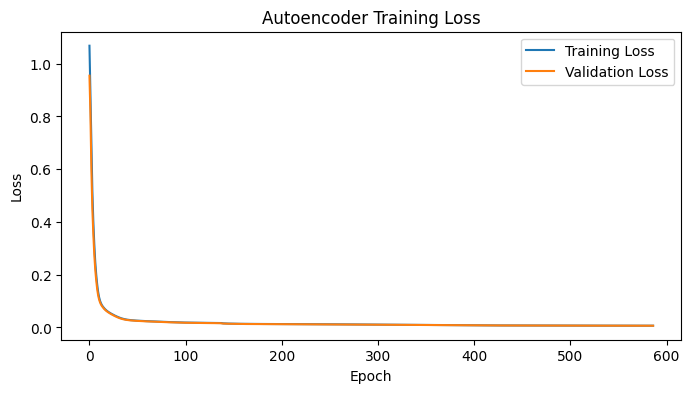

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.savefig("../figures/training_loss.png", bbox_inches="tight")
plt.show()


In [19]:
fault1_dataset       = dataset[dataset['Fault'] == 1].drop("Fault", axis=1)
fault_type1          = fault1_dataset.values
faulty_transformeddata = pipeline.transform(fault_type1)

fault2_dataset       = dataset[dataset['Fault'] == 2].drop("Fault", axis=1)
fault3_dataset       = dataset[dataset['Fault'] == 3].drop("Fault", axis=1)
fault_type2          = fault2_dataset.values
fault_type3          = fault3_dataset.values
faulty_transformeddata2 = pipeline.transform(fault_type2)
faulty_transformeddata3 = pipeline.transform(fault_type3)


In [20]:
reconstruction_errors_normal_test = np.mean(
    np.abs(test_transformed - model.predict(test_transformed)), axis=1)
reconstruction_loss_fault1 = np.mean(
    np.abs(faulty_transformeddata  - model.predict(faulty_transformeddata)),  axis=1)
reconstruction_loss_fault2 = np.mean(
    np.abs(faulty_transformeddata2 - model.predict(faulty_transformeddata2)), axis=1)
reconstruction_loss_fault3 = np.mean(
    np.abs(faulty_transformeddata3 - model.predict(faulty_transformeddata3)), axis=1)

print(f"Avg reconstruction loss - Healthy: {np.mean(reconstruction_errors_normal_test):.6f}")
print(f"Avg reconstruction loss - Fault 1: {np.mean(reconstruction_loss_fault1):.6f}")
print(f"Avg reconstruction loss - Fault 2: {np.mean(reconstruction_loss_fault2):.6f}")
print(f"Avg reconstruction loss - Fault 3: {np.mean(reconstruction_loss_fault3):.6f}")


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step
Avg reconstruction loss - Healthy: 0.057320
Avg reconstruction loss - Fault 1: 0.457901
Avg reconstruction loss - Fault 2: 0.397074
Avg reconstruction loss - Fault 3: 0.412307


In [21]:
for name, loss in [("Fault 1", reconstruction_loss_fault1),
                   ("Fault 2", reconstruction_loss_fault2),
                   ("Fault 3", reconstruction_loss_fault3)]:
    ratio = np.mean(loss) / np.mean(reconstruction_errors_normal_test)
    print(f"{name} loss is {ratio:.1f}x higher than healthy")


Fault 1 loss is 8.0x higher than healthy
Fault 2 loss is 6.9x higher than healthy
Fault 3 loss is 7.2x higher than healthy


## Realistic Test Set

Fault samples are subsampled to 200 per fault type (~17% overall fault rate),
matching the subsampling used in the Isolation Forest notebook for a consistent
and fair comparison between both models.


In [22]:
N_PER_FAULT = 200

np.random.seed(SEED)
idx1 = np.random.choice(len(faulty_transformeddata),  N_PER_FAULT, replace=False)
idx2 = np.random.choice(len(faulty_transformeddata2), N_PER_FAULT, replace=False)
idx3 = np.random.choice(len(faulty_transformeddata3), N_PER_FAULT, replace=False)

fault_sample1 = faulty_transformeddata[idx1]
fault_sample2 = faulty_transformeddata2[idx2]
fault_sample3 = faulty_transformeddata3[idx3]

all_test = np.vstack([
    test_transformed,
    fault_sample1,
    fault_sample2,
    fault_sample3
])

all_labels = np.array(
    [0] * len(test_transformed) +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT
)

fault_rate = (N_PER_FAULT * 3) / len(all_labels)
print(f"Healthy:    {len(test_transformed)}")
print(f"Fault:      {N_PER_FAULT * 3}")
print(f"Fault rate: {fault_rate:.1%}")


Healthy:    3200
Fault:      600
Fault rate: 15.8%


In [23]:
reconstructions_all = model.predict(all_test)
errors = np.mean(np.abs(all_test - reconstructions_all), axis=1)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step


## Threshold Optimization




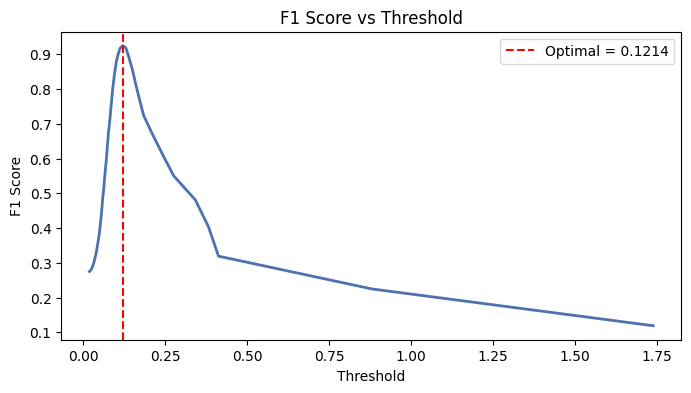

Optimal threshold: 0.1214
Best F1:           0.9248


In [ ]:
from sklearn.metrics import f1_score

thresholds = np.percentile(errors, np.arange(1, 100, 1))

f1_scores = [
    f1_score(all_labels, (errors > t).astype(int))
    for t in thresholds
]

optimal_threshold = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color="#4C72B0", linewidth=2)
plt.axvline(
    optimal_threshold,
    color="red",
    linestyle="--",
    label=f"Optimal = {optimal_threshold:.4f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.savefig("../figures/threshold_optimization.png", bbox_inches="tight")
plt.show()

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Best F1:           {max(f1_scores):.4f}")

# Final predictions
preds_ae = (errors > optimal_threshold).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


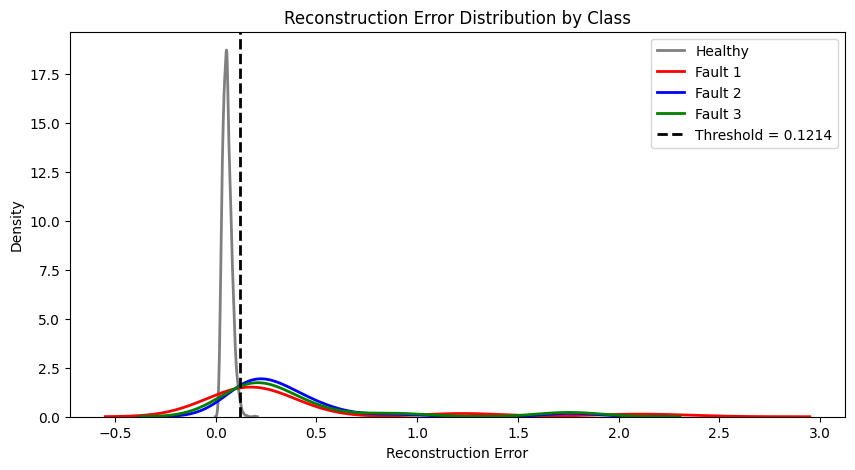

In [26]:
import seaborn as sns

errors_sample1 = np.mean(np.abs(fault_sample1 - model.predict(fault_sample1)), axis=1)
errors_sample2 = np.mean(np.abs(fault_sample2 - model.predict(fault_sample2)), axis=1)
errors_sample3 = np.mean(np.abs(fault_sample3 - model.predict(fault_sample3)), axis=1)

plt.figure(figsize=(10, 5))
for err, label, color in [
    (reconstruction_errors_normal_test, "Healthy", "grey"),
    (errors_sample1,                    "Fault 1", "red"),
    (errors_sample2,                    "Fault 2", "blue"),
    (errors_sample3,                    "Fault 3", "green"),
]:
    sns.kdeplot(err, label=label, color=color, linewidth=2)

plt.axvline(optimal_threshold, color="black", linestyle="--",
            linewidth=2, label=f"Threshold = {optimal_threshold:.4f}")
plt.xlabel("Reconstruction Error")
plt.title("Reconstruction Error Distribution by Class")
plt.legend()
plt.savefig("../figures/reconstruction_error_dist.png", bbox_inches="tight")
plt.show()


In [27]:
preds_ae   = (errors > optimal_threshold).astype(int)
roc_auc_ae = roc_auc_score(all_labels, errors)
f1_ae      = f1_score(all_labels, preds_ae)
recall_ae  = recall_score(all_labels, preds_ae)

print("=== Autoencoder Results ===")
print(f"ROC-AUC:   {roc_auc_ae:.4f}")
print(f"F1:        {f1_ae:.4f}")
print(f"Recall:    {recall_ae:.4f}")
print(f"Precision: {precision_score(all_labels, preds_ae):.4f}")


=== Autoencoder Results ===
ROC-AUC:   0.9897
F1:        0.9248
Recall:    0.9017
Precision: 0.9491


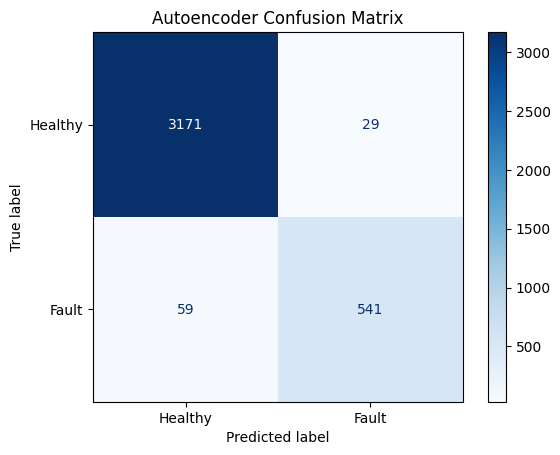

In [28]:
ConfusionMatrixDisplay(
    confusion_matrix(all_labels, preds_ae),
    display_labels=["Healthy", "Fault"]
).plot(cmap="Blues")
plt.title("Autoencoder Confusion Matrix")
plt.savefig("../figures/ae_confusion_matrix.png", bbox_inches="tight")
plt.show()


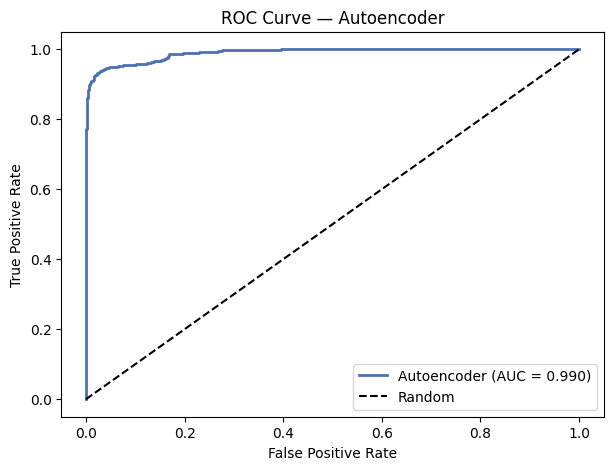

In [29]:
fpr_ae, tpr_ae, _ = roc_curve(all_labels, errors)

plt.figure(figsize=(7, 5))
plt.plot(fpr_ae, tpr_ae, color="#4C72B0", linewidth=2,
         label=f"Autoencoder (AUC = {roc_auc_ae:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Autoencoder")
plt.legend()
plt.savefig("../figures/roc_curve_ae.png", bbox_inches="tight")
plt.show()


## Comparison with Isolation Forest and PCA

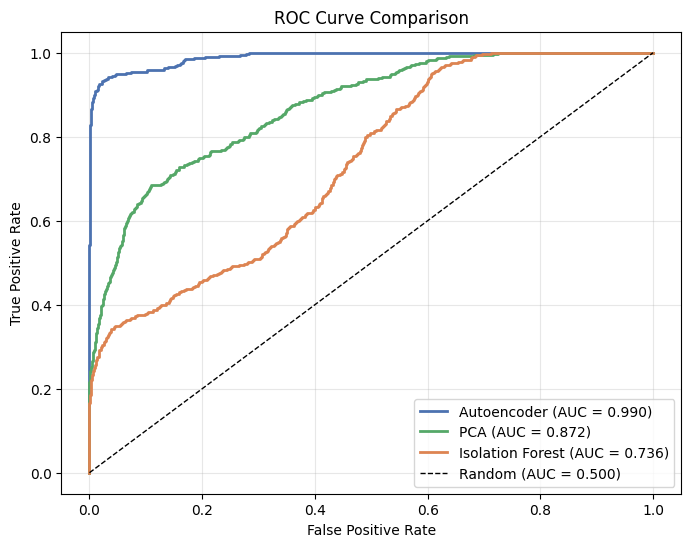

In [34]:
iso_model  = joblib.load("../models/isolation_forest.pkl")
pca = joblib.load("../models/pca_baseline.pkl")
# Isolation Forest scores
if_scores  = -iso_model.decision_function(all_test)
roc_auc_if = roc_auc_score(all_labels, if_scores)
fpr_if, tpr_if, _ = roc_curve(all_labels, if_scores)


pca_errors = np.mean(
    np.abs(
        all_test -
        pca.inverse_transform(pca.transform(all_test))
    ),
    axis=1
)

roc_auc_pca = roc_auc_score(all_labels, pca_errors)
fpr_pca, tpr_pca, _ = roc_curve(all_labels, pca_errors)
# ROC comparison
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_ae, tpr_ae,
    color="#4C72B0",
    linewidth=2,
    label=f"Autoencoder (AUC = {roc_auc_ae:.3f})"
)

plt.plot(
    fpr_pca, tpr_pca,
    color="#55A868",
    linewidth=2,
    label=f"PCA (AUC = {roc_auc_pca:.3f})"
)

plt.plot(
    fpr_if, tpr_if,
    color="#DD8452",
    linewidth=2,
    label=f"Isolation Forest (AUC = {roc_auc_if:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    "k--",
    linewidth=1,
    label="Random (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../figures/roc_curve_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
# Isolation Forest threshold optimization
thresholds_if = np.percentile(if_scores, np.arange(1, 100, 1))
f1_scores_if  = [f1_score(all_labels, (if_scores > t).astype(int))
                 for t in thresholds_if]
opt_thr_if    = thresholds_if[np.argmax(f1_scores_if)]
preds_if      = (if_scores > opt_thr_if).astype(int)


# PCA threshold optimization
thresholds_pca = np.percentile(pca_errors, np.arange(1, 100, 1))
f1_scores_pca = [
    f1_score(all_labels, (pca_errors > t).astype(int))
    for t in thresholds_pca
]
opt_thr_pca = thresholds_pca[np.argmax(f1_scores_pca)]
preds_pca = (pca_errors > opt_thr_pca).astype(int)

results = pd.DataFrame({
    "Model": [
        "Isolation Forest (baseline)",
        "PCA (baseline)",
        "Autoencoder (method)"
    ],
    "ROC-AUC": [
        round(roc_auc_if, 4),
        round(roc_auc_pca, 4),
        round(roc_auc_ae, 4)
    ],
    "F1": [
        round(f1_score(all_labels, preds_if), 4),
        round(f1_score(all_labels, preds_pca), 4),
        round(f1_ae, 4)
    ],
    "Recall": [
        round(recall_score(all_labels, preds_if), 4),
        round(recall_score(all_labels, preds_pca), 4),
        round(recall_ae, 4)
    ],
    "Precision": [
        round(precision_score(all_labels, preds_if), 4),
        round(precision_score(all_labels, preds_pca), 4),
        round(precision_score(all_labels, preds_ae), 4)
    ]
})

print(results.to_string(index=False))

                      Model  ROC-AUC     F1  Recall  Precision
Isolation Forest (baseline)   0.7360 0.4374  0.3433     0.6023
             PCA (baseline)   0.8717 0.6142  0.6183     0.6102
       Autoencoder (method)   0.9897 0.9248  0.9017     0.9491


In [32]:
model.save("../models/autoencoder.keras")
print("Saved → ../models/autoencoder.keras")


Saved → ../models/autoencoder.keras
